# 02 — Relation entre la consommation, la météo et le calendrier

## Objectif

L'énoncé demande une exploration qui fasse apparaître **la relation avec la météo** et **les effets
calendaires**. Ce notebook y répond, et en tire des conséquences concrètes pour les modèles :
quelles variables construire, et sous quelle forme.

## Une règle importante : seulement 2016-2022

Cette exploration sert à **choisir les variables** des modèles. Elle n'utilise donc que la
**période d'apprentissage (2016-2022)**. Si on regardait 2023 (validation) ou 2024-2025 (test),
nos choix seraient influencés par les années qui servent à les juger. Le premier confinement
(du 10 mars au 24 mai 2020, avec une semaine de marge) est retiré des moyennes : c'est un régime
exceptionnel.

## Les étapes

1. Charger la consommation, les températures et le calendrier, par jour
2. La consommation en fonction de la température : la « crosse de hockey »
3. L'effet retardé du froid (inertie des bâtiments)
4. Les trois températures France candidates
5. Les effets du calendrier : jours fériés, ponts, Noël, vacances, août
6. Ce qu'on en retient pour les modèles

## Où sont les données ?

- consommation : `src/rte.py` (notebook 01) ;
- températures France candidates : `src/temperature_france.py` (pipeline météo) ;
- calendrier : `src/calendrier.py`.

Ce notebook ne fait que **décrire** : il ne crée aucune variable pour les modèles. Les variables
seront construites, sans fuite, dans `src/features.py` (table à 14 h).

In [1]:
import sys
from pathlib import Path

import holidays
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RACINE = Path.cwd().resolve()
while not (RACINE / "src").exists() and RACINE != RACINE.parent:
    RACINE = RACINE.parent
sys.path.insert(0, str(RACINE))

from src import config, rte, temperature_france
from src.calendrier import FICHIER_CALENDRIER

pd.set_option("display.width", 140)

BLEU, ORANGE, VERT = "#2a78d6", "#eb6834", "#1baf7a"
ENCRE, GRIS_TEXTE = "#2b3440", "#52514e"
plt.rcParams.update({
    "figure.figsize": (11, 4), "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": GRIS_TEXTE, "xtick.color": GRIS_TEXTE,
    "ytick.color": GRIS_TEXTE, "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "axes.titleweight": "bold", "axes.titlesize": 12, "lines.linewidth": 1.5,
})

## 1. Les données, jour par jour, en heure de Paris

Je fais la moyenne de chaque journée (heure de Paris), puis je garde uniquement la période
d'apprentissage. J'utilise `temp_38_simple` pour les illustrations ; on vérifie à l'étape 4 que
les deux autres candidates donnent les mêmes conclusions.

In [5]:
consommation = rte.lire_prepare()["consommation_MW"]
temperatures = pd.read_csv(temperature_france.FICHIER_SORTIE, index_col=0, parse_dates=True)
calendrier = pd.read_csv(FICHIER_CALENDRIER, parse_dates=["date"]).set_index("date")

def par_jour(serie):
    """Moyenne de chaque journée, en heure de Paris."""
    serie = serie.copy()
    serie.index = serie.index.tz_convert(config.FUSEAU)
    jour = serie.resample("D").mean()
    jour.index = jour.index.tz_localize(None).normalize()
    return jour

jours = pd.DataFrame({
    "conso_GW": par_jour(consommation) / 1000,
    **{nom: par_jour(temperatures[nom]) for nom in config.TEMPERATURE_FRANCE_CANDIDATES},
}).join(calendrier)

# Période d'apprentissage uniquement, sans le premier confinement (+ une semaine de marge)
debut, fin = config.DECOUPAGE["apprentissage"]
jours = jours.loc[str(debut):str(fin)]
jours = jours[~((jours.index >= "2020-03-10") & (jours.index <= "2020-05-24"))]

# Jours de travail « normaux » : en semaine, ni férié, ni pont, ni période de Noël
normal = (jours["weekend"] == 0) & (jours["ferie"] == 0) & (jours["pont_potentiel"] == 0) \
    & (jours["periode_noel"] == 0)
print(f"{len(jours)} jours étudiés, dont {normal.sum()} jours de travail normaux")

2481 jours étudiés, dont 1665 jours de travail normaux


## 2. La consommation en fonction de la température

Pour voir l'effet de la température seule, je ne garde que les **jours de travail normaux** :
sinon les week-ends et les fériés, qui consomment moins, brouilleraient la relation.

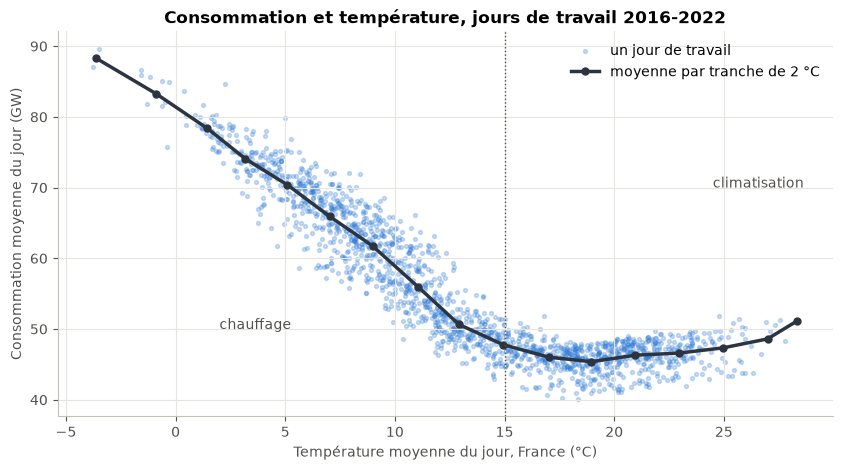

,temp,conso
temp_38_simple,,
"(-4, -2]",-3.6,88.3
"(-2, 0]",-0.9,83.3
"(0, 2]",1.5,78.4
"(2, 4]",3.2,74.1
"(4, 6]",5.1,70.4
"(6, 8]",7.0,65.9
"(8, 10]",9.0,61.7
"(10, 12]",11.1,56.0
"(12, 14]",12.9,50.6


In [6]:
jn = jours[normal]
classes = pd.cut(jn["temp_38_simple"], range(-6, 32, 2))
moyennes = jn.groupby(classes, observed=True).agg(temp=("temp_38_simple", "mean"), conso=("conso_GW", "mean"))

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(jn["temp_38_simple"], jn["conso_GW"], s=8, color=BLEU, alpha=0.25, label="un jour de travail")
ax.plot(moyennes["temp"], moyennes["conso"], color=ENCRE, linewidth=2.5, marker="o", markersize=5,
        label="moyenne par tranche de 2 °C")
ax.axvline(15, color=GRIS_TEXTE, linewidth=1, linestyle=":")
ax.annotate("chauffage", (2, 50), color=GRIS_TEXTE, fontsize=10)
ax.annotate("climatisation", (24.5, 70), color=GRIS_TEXTE, fontsize=10)
ax.set_xlabel("Température moyenne du jour, France (°C)")
ax.set_ylabel("Consommation moyenne du jour (GW)")
ax.set_title("Consommation et température, jours de travail 2016-2022")
ax.legend(frameon=False)
plt.show()

moyennes.round(1)

In [7]:
# Combien coûte un degré en moins ? Pente de la droite sur les jours plus froids que 15 °C
froid = jn[jn["temp_38_simple"] < 15]
pente_froid = np.polyfit(froid["temp_38_simple"], froid["conso_GW"], 1)[0]
chaud = jn[jn["temp_38_simple"] > 22]
pente_chaud = np.polyfit(chaud["temp_38_simple"], chaud["conso_GW"], 1)[0]
print(f"Sous 15 °C : {pente_froid * 1000:+,.0f} MW par degré en plus")
print(f"Au-dessus de 22 °C : {pente_chaud * 1000:+,.0f} MW par degré en plus ({len(chaud)} jours)")

# Variable non linéaire : de combien il fait plus froid que 15 °C (« degrés de chauffe »)
degres_chauffe = (15 - jn["temp_38_simple"]).clip(lower=0)
print(f"\nCorrélation avec la température brute : {jn['conso_GW'].corr(jn['temp_38_simple']):+.3f}")
print(f"Corrélation avec les degrés de chauffe : {jn['conso_GW'].corr(degres_chauffe):+.3f}")

Sous 15 °C : -2,378 MW par degré en plus
Au-dessus de 22 °C : +479 MW par degré en plus (131 jours)

Corrélation avec la température brute : -0.893
Corrélation avec les degrés de chauffe : +0.961


**Ce que je lis :**
- La relation a la forme d'une **crosse de hockey** : quand il fait froid, la consommation monte
  fortement (environ **88 GW** vers −3 °C) ; elle est au plus bas vers **17-20 °C** (environ 45 GW) ;
  elle remonte un peu quand il fait chaud (climatisation, environ 51 GW vers 29 °C).
- **Sous 15 °C, chaque degré en moins coûte environ 2 400 MW.** C'est l'ordre de grandeur publié par
  RTE pour la France, ce qui confirme que nos données sont cohérentes.
- Au-dessus de 22 °C, l'effet de la chaleur est **4 à 5 fois plus faible** (environ +500 MW par degré)
  et ne concerne que peu de jours.
- La relation n'est **pas une droite** : une variable « **de combien il fait plus froid que 15 °C** »
  (les degrés de chauffe) est bien plus liée à la consommation (corrélation 0,96) que la température
  brute (−0,89).

 **Pour les modèles :** utiliser des degrés de chauffe `max(0, 15 − T)` (et éventuellement de
climatisation `max(0, T − 22)`), pas seulement la température brute. C'est indispensable pour la
régression linéaire M2 ; le gradient boosting (M3) peut trouver la forme seul.

## 3. L'effet retardé du froid : l'inertie des bâtiments

Un bâtiment ne refroidit pas instantanément. La consommation d'aujourd'hui dépend donc aussi du
froid **des jours précédents**. Je compare deux façons de résumer la température :
- la température **de la veille, de l'avant-veille…** (décalée) ;
- une température **lissée** : une moyenne des jours passés où les jours récents comptent plus
  (lissage exponentiel : plus le coefficient α est petit, plus on se souvient longtemps du passé).

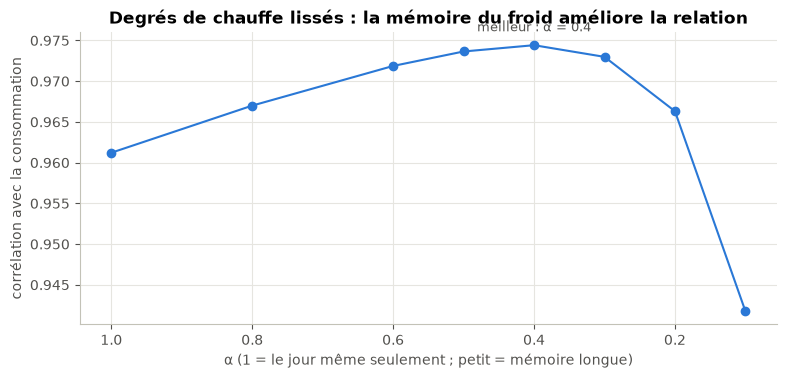

Degrés de chauffe du jour J-k : {'J-0': np.float64(0.961), 'J-1': np.float64(0.956), 'J-2': np.float64(0.935), 'J-3': np.float64(0.913)}


,alpha,corrélation
0,1.0,0.961
1,0.8,0.967
2,0.6,0.972
3,0.5,0.974
4,0.4,0.974
5,0.3,0.973
6,0.2,0.966
7,0.1,0.942


In [8]:
temp = jours["temp_38_simple"]
lignes = []
for alpha in [1.0, 0.8, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]:
    lisse = temp.ewm(alpha=alpha).mean()          # uniquement le passé et le jour même
    chauffe = (15 - lisse).clip(lower=0)
    lignes.append({"alpha": alpha, "corrélation": jours.loc[normal, "conso_GW"].corr(chauffe[normal])})
lissage = pd.DataFrame(lignes)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(lissage["alpha"], lissage["corrélation"], color=BLEU, marker="o", markersize=6)
meilleur = lissage.loc[lissage["corrélation"].idxmax()]
ax.annotate(f"meilleur : α = {meilleur['alpha']:.1f}", (meilleur["alpha"], meilleur["corrélation"]),
            textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color=GRIS_TEXTE)
ax.set_xlabel("α (1 = le jour même seulement ; petit = mémoire longue)")
ax.set_ylabel("corrélation avec la consommation")
ax.invert_xaxis()
ax.set_title("Degrés de chauffe lissés : la mémoire du froid améliore la relation")
plt.show()

decales = {k: jours.loc[normal, "conso_GW"].corr((15 - temp.shift(k)).clip(lower=0)[normal]) for k in range(4)}
print("Degrés de chauffe du jour J-k :", {f"J-{k}": round(v, 3) for k, v in decales.items()})
lissage.round(3)

**Ce que je lis :**
- La température **lissée** sur quelques jours (α ≈ 0,4 à 0,5, soit une demi-vie d'environ 1 à 1,4 jour)
  est plus liée à la consommation (corrélation ≈ 0,974) que la température du jour seul (≈ 0,961).
- Prise seule, la température de la veille est à peine moins bonne que celle du jour (≈ 0,956), et
  celle de l'avant-veille reste utile (≈ 0,935).

 **Pour les modèles (scénario opérationnel) :** à 14 h le jour J, on ne connaît pas la température
de J+1. C'est justement là que l'inertie aide : une **température lissée calculée jusqu'à l'origine
de prévision** (observations jusqu'à 13 h le jour J) porte une bonne partie de l'information utile
pour J+1. Elle devra être calculée dans `src/features.py` **uniquement avec le passé**.

## 4. Les trois températures France candidates

Description seulement : le **choix** se fera sur la validation 2023 avec le modèle M2
(décision 8). Ici, je vérifie juste qu'elles racontent la même histoire.

In [9]:
resume = pd.DataFrame({
    nom: {
        "corrélation conso / température": jours.loc[normal, "conso_GW"].corr(jours.loc[normal, nom]),
        "corrélation conso / degrés de chauffe": jours.loc[normal, "conso_GW"].corr(
            (15 - jours.loc[normal, nom]).clip(lower=0)),
        "température moyenne (°C)": jours[nom].mean(),
    }
    for nom in config.TEMPERATURE_FRANCE_CANDIDATES
}).T
resume.round(3)

,corrélation conso / température,corrélation conso / degrés de chauffe,température moyenne (°C)
temp_8_villes,-0.895,0.960,13.570
temp_38_simple,-0.893,0.961,12.896
temp_38_ponderee,-0.892,0.961,12.772


**Ce que je lis :** les trois candidates ont **presque la même corrélation** avec la consommation
(différence au troisième chiffre après la virgule). La pondérée est un peu plus froide en moyenne
(elle donne plus de poids au nord, plus peuplé). Le choix entre elles risque donc de **peu changer
les résultats** : c'est un résultat à écrire tel quel dans le rapport, et la comparaison avec M2 sur
2023 dira si la différence compte quand même pour la prévision heure par heure.

## 5. Les effets du calendrier

### Comment je mesure l'effet d'un jour particulier

Pour savoir si un jour férié consomme moins, il faut le comparer à un jour « équivalent » : même jour
de la semaine, même saison, même météo. Je le compare à la **moyenne du même jour de la semaine, une
semaine avant et une semaine après**. L'écart, en pourcentage, mesure l'effet du jour.

**Limite :** quand le jour de comparaison est lui-même particulier, l'effet est **sous-estimé**. C'est
le cas du 1er et du 8 mai (l'un sert de référence à l'autre) et du 1er janvier (référence : 25 décembre).

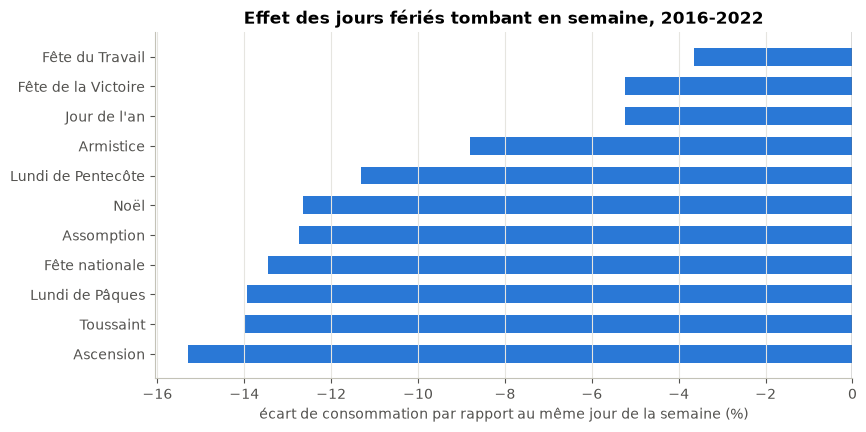

férié en semaine (moyenne)                   -11.3
pont                                          -7.6
veille de férié (jour ouvré)                  -2.7
lendemain de férié (jour ouvré, hors pont)    -2.5
Name: écart moyen (%), dtype: float64

In [10]:
conso = jours["conso_GW"]
# Référence : même jour de la semaine, 7 jours avant et 7 jours après (description seulement)
reference = (conso.shift(7) + conso.shift(-7)) / 2
jours["ecart_pct"] = (conso / reference - 1) * 100
noms_feries = holidays.France(years=range(debut.year, fin.year + 1))
jours["nom_ferie"] = [noms_feries.get(jour.date()) for jour in jours.index]

feries = jours[(jours["ferie"] == 1) & (jours["jour_semaine"] < 5)]
par_ferie = feries.groupby("nom_ferie")["ecart_pct"].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(par_ferie.index, par_ferie.values, color=BLEU, height=0.6)
ax.axvline(0, color=GRIS_TEXTE, linewidth=1)
ax.set_xlabel("écart de consommation par rapport au même jour de la semaine (%)")
ax.set_title("Effet des jours fériés tombant en semaine, 2016-2022")
ax.grid(axis="y", visible=False)
plt.show()

autres = {
    "férié en semaine (moyenne)": feries["ecart_pct"].mean(),
    "pont": jours.loc[jours["pont_potentiel"] == 1, "ecart_pct"].mean(),
    "veille de férié (jour ouvré)": jours.loc[(jours["veille_ferie"] == 1) & (jours["ferie"] == 0)
                                              & (jours["jour_semaine"] < 5), "ecart_pct"].mean(),
    "lendemain de férié (jour ouvré, hors pont)": jours.loc[(jours["lendemain_ferie"] == 1) & (jours["ferie"] == 0)
        & (jours["jour_semaine"] < 5) & (jours["pont_potentiel"] == 0), "ecart_pct"].mean(),
}
pd.Series(autres, name="écart moyen (%)").round(1)

**Ce que je lis :**
- Un **jour férié en semaine** consomme en moyenne environ **11 % de moins** qu'un jour normal : un
  peu comme un dimanche. L'effet varie selon la fête : jusqu'à −15 % pour l'Ascension, environ −13 %
  pour Pâques, le 14 juillet ou le 15 août.
- Le 1er mai, le 8 mai et le 1er janvier semblent moins touchés, mais c'est la **limite de la méthode**
  (leur jour de comparaison est lui aussi spécial).
- Un **pont** consomme environ **8 % de moins** : beaucoup de gens ne travaillent pas.
- La **veille** et le **lendemain** d'un férié consomment un peu moins (environ −2,5 à −3 %).

**Pour les modèles :** les variables `ferie`, `pont_potentiel`, `veille_ferie`, `lendemain_ferie`
sont justifiées. Les benchmarks se trompent justement le plus sur ces jours (notebook 03).

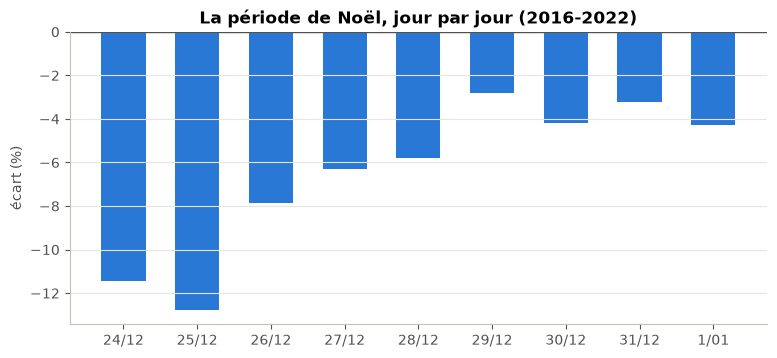

In [8]:
noel = jours[jours["periode_noel"] == 1]
par_jour_noel = noel.groupby([noel.index.month, noel.index.day])["ecart_pct"].mean()
etiquettes = [f"{j}/{m:02d}" for m, j in par_jour_noel.index]
ordre = list(range(1, len(etiquettes))) + [0]   # du 24/12 au 31/12, puis le 1/01

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar([etiquettes[i] for i in ordre], par_jour_noel.values[ordre], color=BLEU, width=0.6)
ax.axhline(0, color=GRIS_TEXTE, linewidth=1)
ax.set_ylabel("écart (%)")
ax.set_title("La période de Noël, jour par jour (2016-2022)")
ax.grid(axis="x", visible=False)
plt.show()

**Ce que je lis :** toute la période du **24 décembre au 1er janvier** consomme moins qu'en temps
normal, pas seulement le jour de Noël : environ −11 % le 24 et −13 % le 25 décembre, puis encore
−3 % à −8 % jusqu'au 1er janvier (beaucoup de gens en congés, entreprises fermées).

**Pour les modèles :** la variable candidate `periode_noel` est justifiée par les données. Son
apport réel sera mesuré sur la validation 2023 (étude d'ablation).

### Les vacances scolaires et le mois d'août

Ma méthode de comparaison ne marche pas pour les vacances : le même jour, une semaine avant ou après,
est souvent **lui aussi** en vacances. Je retire donc d'abord ce qui est connu (le froid, la chaleur,
le jour de la semaine et la tendance d'une année à l'autre) avec une régression simple sur les jours de
travail normaux, puis je regarde **ce qui reste** selon le calendrier.

In [11]:
jn = jours[normal].copy()
jn["chauffe"] = (15 - jours["temp_38_simple"].ewm(alpha=0.4).mean()).clip(lower=0)[normal]
jn["clim"] = (jn["temp_38_simple"] - 22).clip(lower=0)
X = np.column_stack(
    [np.ones(len(jn)), jn["chauffe"], jn["clim"], jn.index.year - debut.year]
    + [(jn["jour_semaine"] == k).astype(float) for k in range(1, 5)]
)
coefficients, *_ = np.linalg.lstsq(X, jn["conso_GW"], rcond=None)
jn["reste_MW"] = (jn["conso_GW"] - X @ coefficients) * 1000

print(f"Effet du froid : {coefficients[1] * 1000:,.0f} MW par degré de chauffe")
print(f"Effet de la chaleur : {coefficients[2] * 1000:,.0f} MW par degré au-dessus de 22 °C")
print(f"Tendance : {coefficients[3] * 1000:+,.0f} MW par an\n")

vacances = jn.groupby("nb_zones_vacances")["reste_MW"].mean().round(0)
aout = {
    "août (tout le mois)": jn.loc[jn.index.month == 8, "reste_MW"].mean(),
    "du 10 au 20 août": jn.loc[(jn.index.month == 8) & (jn.index.day.isin(range(10, 21))), "reste_MW"].mean(),
}
print("Consommation restante selon le nombre de zones en vacances (MW) :")
print(vacances.to_string())
print("\n" + "\n".join(f"{k} : {v:+,.0f} MW" for k, v in aout.items()))

Effet du froid : 2,530 MW par degré de chauffe
Effet de la chaleur : 610 MW par degré au-dessus de 22 °C
Tendance : -410 MW par an

Consommation restante selon le nombre de zones en vacances (MW) :
nb_zones_vacances
0.0    338.0
1.0   -297.0
2.0   -207.0
3.0   -810.0

août (tout le mois) : -2,223 MW
du 10 au 20 août : -3,697 MW


**Ce que je lis :**
- Les **vacances scolaires** ont un **petit effet** : environ −200 à −300 MW quand une ou deux zones
  sont en vacances, et environ −800 MW (−1,6 %) quand les trois le sont. L'effet n'augmente pas
  régulièrement avec le nombre de zones : sur 7 ans de données, ces petits écarts sont fragiles.
  Une seule variable `nb_zones_vacances` suffit (au lieu de trois) ; son apport sera vérifié sur 2023.
- Le **mois d'août** a un effet beaucoup plus fort : environ **−2,2 GW**, et **−3,7 GW autour du
  15 août** (fermetures d'usines et de bureaux), en plus de ce qu'explique la température.
- La consommation **baisse d'environ 410 MW par an** à température égale : c'est la tendance de fond
  (efficacité énergétique, sobriété) déjà vue dans le notebook 01. Elle justifie la **réestimation
  mensuelle** des modèles et l'usage des retards de consommation, qui suivent le niveau récent.

**Pour les modèles :** garder `nb_zones_vacances`, le **mois** (qui capte l'effet d'août), et
laisser les retards de consommation suivre la tendance.

## 6. Ce qu'on retient pour les modèles

| Constat (2016-2022) | Variable à construire (sans fuite, dans `src/features.py`) | Pour quel modèle |
|---|---|---|
| Relation en crosse de hockey, environ −2 400 MW par °C sous 15 °C | Degrés de chauffe `max(0, 15 − T)` et de climatisation `max(0, T − 22)` | M2 (indispensable), M3 |
| Inertie : la température lissée sur environ 1 à 1,4 jour est la plus liée | Température lissée calculée **jusqu'à 13 h le jour J** | M2, M3 |
| Les 3 températures candidates sont presque équivalentes | Garder les trois pour la comparaison avec M2 sur 2023 | Choix décision 8 |
| Jours fériés : environ −11 % ; ponts : environ −8 % ; veille et lendemain : environ −3 % | `ferie`, `pont_potentiel`, `veille_ferie`, `lendemain_ferie` du jour J+1 | M1, M2, M3 |
| Période de Noël : de −3 % à −13 % pendant 9 jours | `periode_noel` (candidate, à tester sur 2023) | M1, M2, M3 |
| Vacances : de −0,2 à −0,8 GW (fragile) ; août : jusqu'à −3,7 GW | `nb_zones_vacances`, `mois` | M1, M2, M3 |
| Tendance d'environ −410 MW par an | Retards de consommation (48 h, 168 h) + réestimation mensuelle | Tous |

**Limites de cette exploration :**
- Elle utilise la température **du jour même** pour décrire la relation. Dans le scénario
  opérationnel, la température de J+1 n'est pas connue à 14 h : c'est tout l'enjeu de l'écart entre
  le modèle opérationnel et le plafond « météo parfaite ».
- Les effets calendaires sont des moyennes sur 2016-2022 ; ils peuvent évoluer (télétravail depuis
  2020, sobriété depuis 2022).